# Training a spiking network to generate a gamma rhythm — with BMTK `dpointnet`

`dpointnet` is BMTK's **differentiable** point-neuron simulator: it runs a GLIF spiking network as a
recurrent network (spikes via a surrogate gradient) so you can **train the synaptic weights by
gradient descent** to make the network *do* something. Earlier tutorials covered building point-neuron
networks with the `NetworkBuilder` and running them; here we take a small built network and **train it
to produce a gamma-band oscillation** (~30–50 Hz).

Gamma is a **population** phenomenon — it lives in the *coordinated* activity of many cells, not in any
single neuron. That makes the interesting part of this tutorial the **loss function**: how do you
write a differentiable objective that rewards a genuine population rhythm (rather than, say, individual
cells merely firing fast) while keeping firing rates realistic? Section 4 walks through the one we use.

**What you'll do:** build the network → run it untrained → train the recurrent and background weights
against a spectral + rate-distribution loss → watch a gamma rhythm emerge in the population activity.
The knobs to experiment with are collected in Section 2 and Section 7.

> Run this in the `dpointnet` conda environment (TensorFlow-GPU). A full run is a few minutes on a
> single GPU.

In [1]:
import os, sys, json
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Run this notebook from its own directory; the helper modules and config live alongside it.
import gamma_viz as gv        # raster / population-rate plot helpers
import gamma_loss as GL       # our custom loss module (registers 'GammaLoss') + a numpy scorer
import build_net              # builds the SONATA network

I0000 00:00:1783664043.944351 1170588 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1783664043.985173 1170588 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1783664072.869570 1170588 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 1. The network

`build_net.py` uses the `NetworkBuilder` (as in the earlier tutorials) to write a small **SONATA**
network that `dpointnet` reads directly:

- **240 excitatory + 60 inhibitory** GLIF point neurons with random recurrent connectivity.
- The inhibitory cells are **fast** (short membrane time constant) with **fast-decaying** inhibitory
  synapses, and there is a short **inhibitory→excitatory conduction delay**.
- A **background** Poisson input that keeps every cell active; it is the only external drive here.

These choices set the timescales available to the network. You don't need to edit them to run the
tutorial — they're documented in `build_net.py`, and Section 7 points to the ones that shift the
frequency the network can be trained toward.

In [2]:
build_net.build('net', force=True)   # writes ./net/{network, components}/

[gamma/dpn] built SONATA net_dir: net  (240 E + 60 I, 4E/4I cell variants, I->E delay 4.0ms, drive=100, bkg=100)


'net'

## 2. Configure the run — your knobs

`dpointnet` is driven by a JSON config (`config.train.json`) — network files, cell parameters, inputs,
and the training block (loss + optimizer). We load it and override the handful of parameters worth
experimenting with. Training adjusts the **recurrent** weights and the **background** weights; the
cell parameters and connectivity are fixed.

In [3]:
# ---- KNOBS (edit these) --------------------------------------------------------------------
BATCH_SIZE     = 16       # background realizations averaged per gradient step. Approx GPU peak
                         # (500 ms rollout): 8 -> ~5 GB, 16 -> ~8-9 GB, 32 -> ~15.7 GB (measured).
                         # Bigger = smoother training, more memory.
TARGET_BAND    = (30.0, 50.0)   # the gamma window to grow (Hz). Must match the network's resonance;
                                # to move it, change build_net.DELAY_IE / BASIS_INH too (Section 7).
RATE_MEDIAN_HZ = 10.0    # target median single-cell firing rate (the rate-distribution loss, Section 4)
N_EPOCHS       = 30      # ~3-6 min depending on BATCH_SIZE
LEARNING_RATE  = 3.3e-4
# --------------------------------------------------------------------------------------------

SPECTRAL_REF = 'full'    # the spectral term compares in-band power to the WHOLE spectrum ('full')
                         # rather than only the neighbouring flanks ('flanks'); see Section 4.

cfg = json.load(open('configs/config.train.json'))
cfg['run']['batch_size'] = BATCH_SIZE
cfg['training']['learning_rate'] = LEARNING_RATE
gl = cfg['training']['parameters'][0]['loss_functions']['gamma']
lo, hi = TARGET_BAND
gl['in_band'] = [lo, hi]
gl['flanks']  = [[lo - 10, lo], [hi, hi + 10]]   # only used when SPECTRAL_REF='flanks'
gl['rate_median_hz'] = RATE_MEDIAN_HZ
gl['spectral_ref'] = SPECTRAL_REF
cfg['training']['callbacks'] = {'class': 'Callbacks', 'verbose': 'quiet', 'epoch_store_weights': 'skip',
                                'losses_table_csv': False, 'performance_table_csv': False}
cfg['training']['n_epochs'] = 1
json.dump(cfg, open('_run.json', 'w'))

from bmtk.simulator import dpointnet
conf = dpointnet.Config.from_json('_run.json'); conf.build_env()
rnn = dpointnet.RNN.from_config(conf); rnn.build()
cell = rnn._cell
print('trainable weights:', [v.name for v in rnn.model.trainable_variables])

# E/I identity; a single all-cell group for the population-mean spectrum; the target-rate spread.
df = rnn.get_recurrent_network().get_nodes_df(); is_exc = (df['ei'].astype(str).values == 'e'); N = len(df)
gi = np.arange(N)[None, :]
SEQ = cfg['run']['seq_len']
RATE_SIGMA = float(gl.get('rate_sigma', 0.6))
_FL = (tuple(gl['flanks'][0]), tuple(gl['flanks'][1]))
WARMUP_MS = 200   # from the zero (at-rest) state the network takes ~100-200 ms to settle. Every
                  # rollout below rolls out this extra leading window and returns ONLY the settled
                  # remainder, so plots and metrics start from steady state with no onset transient.

def roll_out(n_steps=SEQ, warmup=WARMUP_MS):
    # Vanilla dpointnet rollout from the zero state (the standard inference path). We roll out an
    # extra `warmup` ms first and return only the settled remainder -> the returned trace runs
    # 0..n_steps ms of steady-state activity. The noise counter is reset first so the evaluation
    # background is reproducible. Returns spikes as [batch, time, neuron].
    saved = cell.noise_step.numpy(); cell.noise_step.assign(0)
    drive = tf.zeros((BATCH_SIZE, warmup + n_steps, build_net.N_DRIVE), tf.float32)
    sp = rnn.run_inference(spikes=drive).spikes.to_spikes_table().numpy()
    cell.noise_step.assign(int(saved))
    return sp[:, warmup:, :]

def pop_spectrum(sp):
    # Population-mean power spectrum, AVERAGED over all batch members (sp is already transient-free
    # via the warm-up in roll_out); scored with the same spectral reference (SPECTRAL_REF) as the
    # training loss. Returns: freqs, mean power, gamma band-contrast, peak frequency.
    r = [GL.band_contrast_np(sp[b], group_idx=gi, in_band=TARGET_BAND, flanks=_FL,
                             spectral_ref=SPECTRAL_REF, t_skip=0) for b in range(sp.shape[0])]
    return r[0][2], np.mean([x[3] for x in r], 0), float(np.mean([x[0] for x in r])), float(np.median([x[1] for x in r]))

def gamma_contrast(sp):
    return pop_spectrum(sp)[2]

def rate_emd(sp):
    # Wasserstein-1 between the per-cell firing-rate distribution and the target lognormal.
    hz = per_cell_rate(sp)
    tgt = np.sort(np.random.default_rng(0).lognormal(np.log(RATE_MEDIAN_HZ), RATE_SIGMA, len(hz)))
    return float(np.mean(np.abs(np.sort(hz) - tgt)))

def per_cell_rate(sp):
    # Per-cell firing rate (Hz), averaged over the batch and the full (transient-free) trace.
    return sp.sum(1).mean(0) / (sp.shape[1] / 1000.0)

2026-07-09 23:14:58,514 [INFO] Created log file


2026-07-09 23:14:58,533 [INFO] TensorFlow precision policy set to "float32" (compute_dtype=float32, variable_dtype=float32, requested_dtype=float32).


INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0',)


2026-07-09 23:14:58,956 [INFO] Building "drive_input" inputs for drive


2026-07-09 23:14:58,957 [INFO] Building "bkg_input" inputs for bkg


I0000 00:00:1783664098.766599 1170588 gpu_process_state.cc:208] Using CUDA malloc Async allocator for GPU: 0
I0000 00:00:1783664098.766858 1170588 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20202 MB memory:  -> device: 0, name: NVIDIA RTX A5000, pci bus id: 0000:b3:00.0, compute capability: 8.6


trainable weights: ['sparse_recurrent_weights', 'bkg_input_weights']


## 3. The untrained network

Before training, the background drives the network into fast, **irregular** activity — there's no
coordinated rhythm, so the raster shows no structure beyond each cell firing on its own. Each rollout
warms up from rest for 200 ms first and returns only the settled activity, so the trace below is a
clean 0–1000 ms of steady-state spiking with no startup transient.

untrained: gamma band-contrast = 0.53


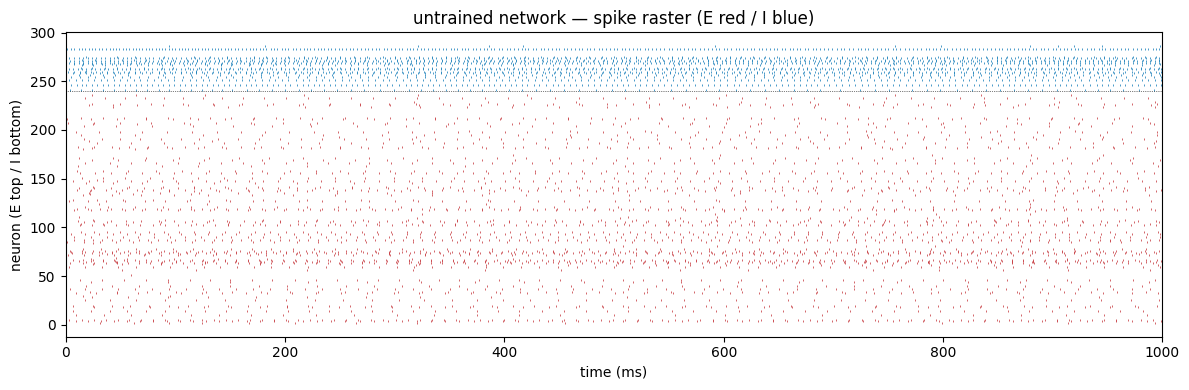

In [4]:
sp_untrained = roll_out(1000)                 # a full 1-second rollout for the initial look
freqs, P_untrained, c0, _ = pop_spectrum(sp_untrained)   # kept for the before/after comparison in Section 6
print(f'untrained: gamma band-contrast = {c0:.2f}')

fig, ax = plt.subplots(figsize=(12, 4))
gv.raster(sp_untrained[0], is_exc, ax=ax, t0=0, t1=1000)
ax.set(xlim=(0, 1000), title='untrained network — spike raster (E red / I blue)')
fig.tight_layout()

## 4. The training objective (the interesting part)

We want the network to develop a **coordinated gamma rhythm** while keeping **realistic firing rates**.
The loss (`gamma_loss.GammaLoss`) is the sum of two differentiable terms:

**(a) A gamma band-contrast — rewards population coordination.**
Take the **population-mean firing rate** `r(t)` (averaged over cells), compute its power spectrum
`P(f)` with a differentiable FFT, and maximize the fraction of power in the target band relative to
the **whole spectrum**:

$$\text{contrast}=\frac{P_{[30,50]}}{P_{[30,50]}+\overline{P}_{\text{all}}}\in[0,1],$$

where $\overline{P}_{\text{all}}$ is the average power across all frequencies.

Two design points matter. First, we take the spectrum **of the population mean** (not the average of
per-cell spectra): power at 40 Hz then requires *many cells to fluctuate together at 40 Hz* — i.e. it
measures genuine **coordination**, and can't be satisfied by isolated cells firing regularly. Second,
measuring in-band power against the **entire spectrum** (rather than only the neighbouring flanks)
penalizes power *anywhere* else — slow low-frequency drift as well as higher-frequency noise — which
gives a smoother, more monotonic training signal. Because the FFT is differentiable, gradients flow
from `P(f)` back through the surrogate-gradient spikes to the recurrent and background weights.

**(b) An EMD rate-distribution term — keeps firing rates realistic.**
Cortical firing rates are roughly **lognormal** (most cells slow, a few faster). We push the
distribution of per-cell rates toward a lognormal (median `RATE_MEDIAN_HZ`) using the
**Earth-Mover's Distance** (Wasserstein-1) between the observed and target rate distributions. This
keeps cells sparsely and realistically active — no silent cells, and no cells running away to
implausibly high rates.

The full objective is `loss = -contrast + w_rate * EMD(rates, lognormal)`. Here's the config block:

In [5]:
print(json.dumps({k: v for k, v in gl.items() if not k.startswith('__')}, indent=2))

{
  "module": "GammaLoss",
  "in_band": [
    30.0,
    50.0
  ],
  "flanks": [
    [
      20.0,
      30.0
    ],
    [
      50.0,
      60.0
    ]
  ],
  "spectral_ref": "full",
  "frame_len": 200,
  "frame_step": 50,
  "n_groups": 1,
  "pop": "all",
  "rate_dist_weight": 0.02,
  "rate_median_hz": 10.0,
  "rate_sigma": 0.6,
  "t_skip_ms": 150
}


## 5. Train

We run the epoch loop ourselves so we can track progress. Two practical notes:
- The background is **random every training step**, which trains a rhythm generator that's robust to
  the input (not overfit to one noise pattern); we **evaluate** on a *fixed* background so the curve
  reflects learning.
- The gamma metric wanders a little epoch-to-epoch (stochastic training), so we keep the weights from
  the **best** epoch.

In [6]:
# epoch-0 baseline (a 500 ms eval, matching the per-epoch evals below)
sp0 = roll_out()
c_base, e_base = gamma_contrast(sp0), rate_emd(sp0)
best = {'c': c_base, 'rec': cell.recurrent_weight_values.numpy(),
        'bkg': cell.inputs['bkg']['input_weight_values'].numpy()}
epochs, curve_contrast, curve_emd = [0], [c_base], [e_base]

for ep in range(1, N_EPOCHS + 1):
    rnn.training_engine.n_epochs = 1; rnn.train()
    if ep % 3 == 0 or ep == N_EPOCHS:
        sp = roll_out()
        c, e = gamma_contrast(sp), rate_emd(sp)
        epochs.append(ep); curve_contrast.append(c); curve_emd.append(e)
        if c > best['c']:
            best = {'c': c, 'rec': cell.recurrent_weight_values.numpy(),
                    'bkg': cell.inputs['bkg']['input_weight_values'].numpy()}
        bestc = best['c']
        print(f'epoch {ep:3d}:  gamma band-contrast = {c:.2f}   rate-EMD = {e:.1f}   (best contrast {bestc:.2f})')

# restore the best-epoch weights
cell.recurrent_weight_values.assign(best['rec']); cell.inputs['bkg']['input_weight_values'].assign(best['bkg'])
if hasattr(cell, 'refresh_recurrent_weight_shadow'): cell.refresh_recurrent_weight_shadow()

I0000 00:00:1783664157.439397 1170588 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


epoch   3:  gamma band-contrast = 0.76   rate-EMD = 15.6   (best contrast 0.76)


epoch   6:  gamma band-contrast = 0.75   rate-EMD = 14.5   (best contrast 0.76)


epoch   9:  gamma band-contrast = 0.84   rate-EMD = 12.9   (best contrast 0.84)


epoch  12:  gamma band-contrast = 0.84   rate-EMD = 11.1   (best contrast 0.84)


...

epoch  18:  gamma band-contrast = 0.86   rate-EMD = 13.9   (best contrast 0.86)


epoch  21:  gamma band-contrast = 0.87   rate-EMD = 12.0   (best contrast 0.87)


epoch  24:  gamma band-contrast = 0.86   rate-EMD = 11.8   (best contrast 0.87)


epoch  27:  gamma band-contrast = 0.87   rate-EMD = 10.9   (best contrast 0.87)


epoch  30:  gamma band-contrast = 0.85   rate-EMD = 11.4   (best contrast 0.87)


## 6. Results — a gamma rhythm emerges

After training, the population-rate spectrum grows a sharp peak in the target band, the raster shows
more structured population activity, and the per-cell firing rates follow the intended lognormal
(shown split into excitatory and inhibitory cells). We save the initial/final spikes and the trained
weights for further analysis.

gamma band-contrast:  0.53 (untrained)  ->  0.88 (trained), peak ~35 Hz


saved: spikes_{untrained,trained}.npz, trained_weights.npz, train_metrics.npz, trained_model/


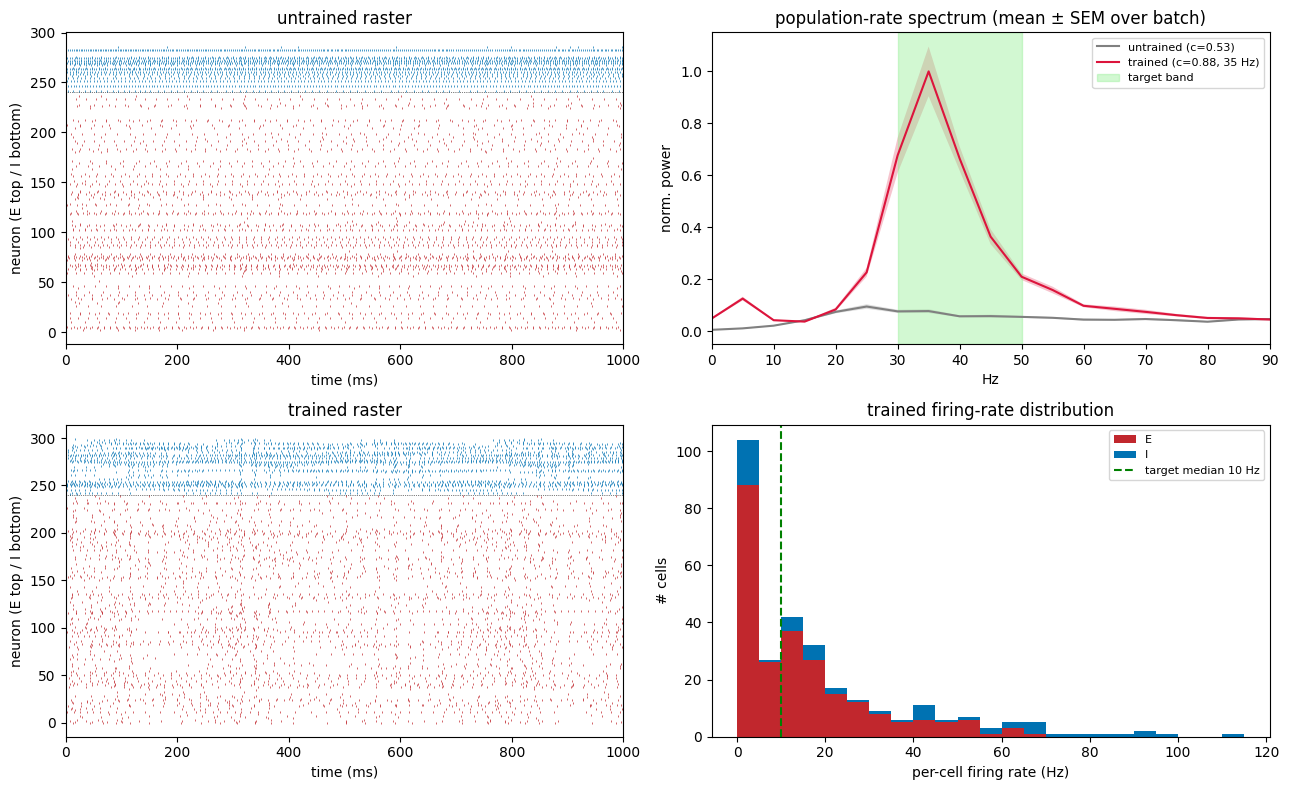

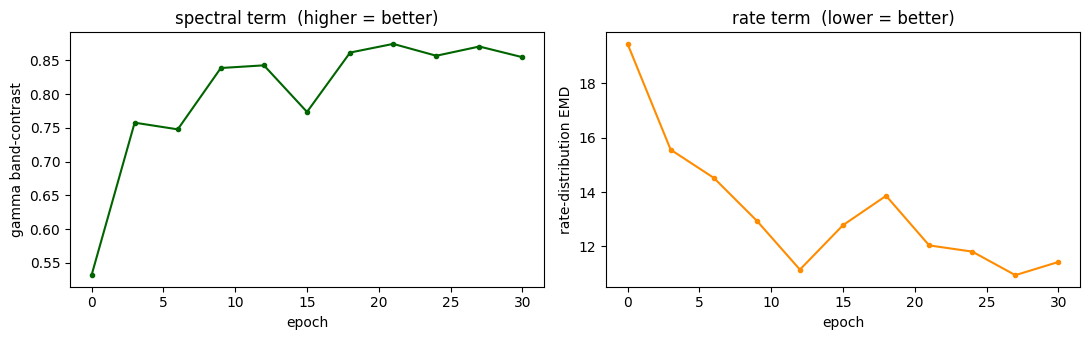

In [7]:
sp_trained = roll_out(1000)                                   # 1-second rollout, matching the untrained one
freqs, P_trained, c1, pk1 = pop_spectrum(sp_trained)          # batch-averaged; warm-up removes the transient
print(f'gamma band-contrast:  {c0:.2f} (untrained)  ->  {c1:.2f} (trained), peak ~{pk1:.0f} Hz')

# ---- save everything for later figure work / reuse -----------------------------------------
os.makedirs('saved', exist_ok=True)
# the full 1-second evaluation batch: ALL BATCH_SIZE instances (each a different background draw),
# so there are several spike sets to choose from when refining figures.
np.savez_compressed('saved/spikes_untrained.npz', spikes=sp_untrained.astype(np.uint8), is_exc=is_exc, dt=1.0)
np.savez_compressed('saved/spikes_trained.npz',   spikes=sp_trained.astype(np.uint8),   is_exc=is_exc, dt=1.0)
np.savez_compressed('saved/trained_weights.npz', recurrent=best['rec'], bkg=best['bkg'])
np.savez_compressed('saved/train_metrics.npz', epochs=np.array(epochs),
                    gamma_contrast=np.array(curve_contrast), rate_emd=np.array(curve_emd),
                    best_contrast=best['c'], target_band=np.array(TARGET_BAND),
                    rate_untrained=per_cell_rate(sp_untrained), rate_trained=per_cell_rate(sp_trained))
try:
    rnn.get_model_weights(deep_copy=True).to_sonata(output_dir='saved/trained_model', overwrite=True)
    print('saved: spikes_{untrained,trained}.npz, trained_weights.npz, train_metrics.npz, trained_model/')
except Exception as e:
    print('trained_model SONATA save skipped:', e)

# ---- before / after figure -----------------------------------------------------------------
E_C, I_C = '#c1272d', '#0072b2'
fig, ax = plt.subplots(2, 2, figsize=(13, 8))
gv.raster(sp_untrained[0], is_exc, ax=ax[0, 0], t0=0, t1=1000); ax[0, 0].set(xlim=(0, 1000), title='untrained raster')
gv.raster(sp_trained[0],   is_exc, ax=ax[1, 0], t0=0, t1=1000); ax[1, 0].set(xlim=(0, 1000), title='trained raster')

# spectrum: mean +/- SEM across the batch (each batch member is an independent background draw)
def _psd_stack(sp):
    return np.array([GL.band_contrast_np(sp[b], group_idx=gi, in_band=TARGET_BAND, flanks=_FL, t_skip=0)[3]
                     for b in range(sp.shape[0])])            # [batch, freq]
Pu, Pt = _psd_stack(sp_untrained), _psd_stack(sp_trained)
nrm = max(Pu.mean(0).max(), Pt.mean(0).max()) + 1e-9
for P, col, lab in [(Pu, 'gray',    f'untrained (c={c0:.2f})'),
                    (Pt, 'crimson', f'trained (c={c1:.2f}, {pk1:.0f} Hz)')]:
    m = P.mean(0) / nrm
    sem = P.std(0, ddof=1) / np.sqrt(P.shape[0]) / nrm       # SEM over batch members
    ax[0, 1].plot(freqs, m, color=col, label=lab)
    ax[0, 1].fill_between(freqs, m - sem, m + sem, color=col, alpha=0.25, linewidth=0)
ax[0, 1].axvspan(*TARGET_BAND, color='#90ee90', alpha=0.4, label='target band')
ax[0, 1].set(xlim=(0, 90), xlabel='Hz', ylabel='norm. power', title='population-rate spectrum (mean ± SEM over batch)')
ax[0, 1].legend(fontsize=8)

hz = per_cell_rate(sp_trained); bins = np.arange(0, 120, 5)
ax[1, 1].hist([hz[is_exc], hz[~is_exc]], bins=bins, stacked=True, color=[E_C, I_C], label=['E', 'I'])
ax[1, 1].axvline(RATE_MEDIAN_HZ, color='green', ls='--', label=f'target median {RATE_MEDIAN_HZ:.0f} Hz')
ax[1, 1].set(xlabel='per-cell firing rate (Hz)', ylabel='# cells', title='trained firing-rate distribution')
ax[1, 1].legend(fontsize=8)
fig.tight_layout()

# ---- training curves: both loss components -------------------------------------------------
fig2, axc = plt.subplots(1, 2, figsize=(11, 3.5))
axc[0].plot(epochs, curve_contrast, '-o', ms=3, color='darkgreen')
axc[0].set(xlabel='epoch', ylabel='gamma band-contrast', title='spectral term  (higher = better)')
axc[1].plot(epochs, curve_emd, '-o', ms=3, color='darkorange')
axc[1].set(xlabel='epoch', ylabel='rate-distribution EMD', title='rate term  (lower = better)')
fig2.tight_layout()

## 7. Optional problems to explore

The questions below are open-ended starting points for your own experiments rather than fully worked
exercises. They build on the same pipeline, so we first package the build-and-train steps into a few
**helper functions** (next cell); the trickier mechanics — rebuilding the network in this kernel,
shuffling weights within connection classes, inspecting a synaptic kernel — are handled there so you
can focus on the science. Each problem is introduced in its own section below.

In [8]:
# ---- helper functions for the problems below ----------------------------------------------
from bmtk.simulator.dpointnet.id_maps import TFIDMap
from bmtk.simulator.dpointnet.network_adaptor import SONATANetwork

def train_network(*, net_dir='net_exp', basis_inh=None, delay_ie=None, target_band=(30., 50.),
                  rate_median_hz=10.0, batch_size=8, n_epochs=25, lr=1.65e-4, seed=0):
    """Package Sections 2-5 into one call, so you can re-run the whole build+train pipeline with
    different settings. Optional overrides: basis_inh (4-value inhibitory synaptic kernel),
    delay_ie (I->E conduction delay, ms), target_band (Hz), rate_median_hz. Returns a dict with the
    trained rnn/cell, a roll_out() bound to them, the E/I mask, and the per-epoch contrast curve."""
    saved_delay = build_net.DELAY_IE
    try:
        if delay_ie is not None:
            build_net.DELAY_IE = float(delay_ie)
        build_net.build(net_dir, force=True, seed=seed, basis_inh=basis_inh)
    finally:
        build_net.DELAY_IE = saved_delay
    cfg = json.load(open('configs/config.train.json'))
    cfg['manifest']['$BASE_DIR'] = net_dir
    cfg['run']['batch_size'] = batch_size
    cfg['training']['learning_rate'] = lr
    g = cfg['training']['parameters'][0]['loss_functions']['gamma']
    blo, bhi = target_band
    g['in_band'] = [blo, bhi]; g['flanks'] = [[blo - 10, blo], [bhi, bhi + 10]]; g['rate_median_hz'] = rate_median_hz
    g['spectral_ref'] = SPECTRAL_REF
    cfg['training']['callbacks'] = {'class': 'Callbacks', 'verbose': 'quiet', 'epoch_store_weights': 'skip',
                                    'losses_table_csv': False, 'performance_table_csv': False}
    cfg['training']['n_epochs'] = 1
    json.dump(cfg, open('_exp.json', 'w'))
    # dpointnet keeps a process-global node/synapse id map (a singleton), so building a second
    # network in the same kernel needs it reset first.
    TFIDMap._tf_id_map_instance = None; TFIDMap._initialized = False
    SONATANetwork.reset_global_syn_id_mapping()
    conf = dpointnet.Config.from_json('_exp.json'); conf.build_env()
    r = dpointnet.RNN.from_config(conf); r.build(); c = r._cell
    dfx = r.get_recurrent_network().get_nodes_df(); ise = (dfx['ei'].astype(str).values == 'e'); Nx = len(dfx)
    gix = np.arange(Nx)[None, :]; flx = (tuple(g['flanks'][0]), tuple(g['flanks'][1]))

    def roll(n_steps=SEQ, warmup=WARMUP_MS):
        sv = c.noise_step.numpy(); c.noise_step.assign(0)
        drive = tf.zeros((batch_size, warmup + n_steps, build_net.N_DRIVE), tf.float32)
        sp = r.run_inference(spikes=drive).spikes.to_spikes_table().numpy()
        c.noise_step.assign(int(sv)); return sp[:, warmup:, :]

    def contr(sp):
        rr = [GL.band_contrast_np(sp[b], group_idx=gix, in_band=target_band, flanks=flx, spectral_ref=SPECTRAL_REF, t_skip=0)
              for b in range(sp.shape[0])]
        return float(np.mean([x[0] for x in rr]))

    epochs_x, curve_x = [0], [contr(roll())]
    best = {'c': curve_x[0], 'rec': c.recurrent_weight_values.numpy(),
            'bkg': c.inputs['bkg']['input_weight_values'].numpy()}
    for ep in range(1, n_epochs + 1):
        r.training_engine.n_epochs = 1; r.train()
        if ep % 5 == 0 or ep == n_epochs:
            cc = contr(roll()); epochs_x.append(ep); curve_x.append(cc)
            if cc > best['c']:
                best = {'c': cc, 'rec': c.recurrent_weight_values.numpy(),
                        'bkg': c.inputs['bkg']['input_weight_values'].numpy()}
    c.recurrent_weight_values.assign(best['rec']); c.inputs['bkg']['input_weight_values'].assign(best['bkg'])
    if hasattr(c, 'refresh_recurrent_weight_shadow'): c.refresh_recurrent_weight_shadow()
    return dict(rnn=r, cell=c, roll_out=roll, is_exc=ise, gi=gix,
                epochs=epochs_x, contrast=curve_x, target_band=target_band)


def spec(sp, gi, band):
    """freqs, mean power (batch-averaged), band-contrast, peak freq -- for an arbitrary band."""
    fl = ((band[0] - 10, band[0]), (band[1], band[1] + 10))
    r = [GL.band_contrast_np(sp[b], group_idx=gi, in_band=band, flanks=fl, spectral_ref=SPECTRAL_REF, t_skip=0) for b in range(sp.shape[0])]
    return r[0][2], np.mean([x[3] for x in r], 0), float(np.mean([x[0] for x in r])), float(np.median([x[1] for x in r]))


def shuffle_recurrent_within_classes(cell, is_exc, seed=0):
    """Randomly permute the trained recurrent weights WITHIN each connection class (E->E, E->I,
    I->E, I->I). This preserves each class's sign and its set of weight magnitudes but destroys the
    specific learned pairing. Modifies the cell in place; returns the shuffled weight vector."""
    idx = cell.recurrent_indices.numpy(); n = cell._n_neurons
    pre_e = is_exc[idx[:, 1] % n]; post_e = is_exc[idx[:, 0] % n]   # col1 = pre (+delay offset), col0 = post
    rec = cell.recurrent_weight_values.numpy().copy(); rng = np.random.default_rng(seed)
    for pe in (True, False):
        for po in (True, False):
            m = (pre_e == pe) & (post_e == po)
            v = rec[m]; rng.shuffle(v); rec[m] = v
    cell.recurrent_weight_values.assign(rec)
    if hasattr(cell, 'refresh_recurrent_weight_shadow'): cell.refresh_recurrent_weight_shadow()
    return rec


def psc_kernel(basis_weights, tau_basis=build_net.TAU_BASIS, dt=1.0, T=120):
    """The postsynaptic current one presynaptic spike produces through a synapse with the given
    4-value basis_weights (reproduces dpointnet's two-state synapse). Use it to SEE what a kernel
    like build_net.BASIS_INH vs BASIS_INH_FAST looks like in time."""
    tau = np.asarray(tau_basis, float); b = np.asarray(basis_weights, float)
    decay = np.exp(-dt / tau); psc_init = np.e / tau
    rise = np.zeros(len(tau)); psc = np.zeros(len(tau)); out = np.zeros(int(T / dt))
    for t in range(len(out)):
        inp = b if t == 0 else 0.0
        rise, psc = rise * decay + inp * psc_init, psc * decay + dt * decay * rise
        out[t] = psc.sum()
    return np.arange(len(out)) * dt, out

### Problem 1 — Retarget the rhythm to a different frequency

In the tutorial the network settles at ~35 Hz. That frequency isn't arbitrary: it is set by how fast
inhibition acts — the inhibitory synaptic decay (`build_net.BASIS_INH`) and the inhibitory→excitatory
conduction delay (`build_net.DELAY_IE`). Faster inhibition and a shorter delay → a higher frequency.

**Try it:** rebuild and retrain toward a different band. `build_net.BASIS_INH_FAST` is a faster
inhibitory kernel; combine it with a shorter `delay_ie` and set `target_band` to the new window.
Does a clean peak appear at the new frequency? How high can you push it before the peak washes out?

[gamma/dpn] built SONATA net_dir: net_p1  (240 E + 60 I, 4E/4I cell variants, I->E delay 2.0ms, drive=100, bkg=100)
2026-07-09 23:20:58,739 [INFO] Created log file


2026-07-09 23:20:58,758 [INFO] TensorFlow precision policy set to "float32" (compute_dtype=float32, variable_dtype=float32, requested_dtype=float32).


INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0',)


2026-07-09 23:20:58,889 [INFO] Building "drive_input" inputs for drive


2026-07-09 23:20:58,890 [INFO] Building "bkg_input" inputs for bkg


high-gamma network: band-contrast 0.91, peak ~75 Hz  (the tutorial network sat at ~35 Hz, c=0.88)


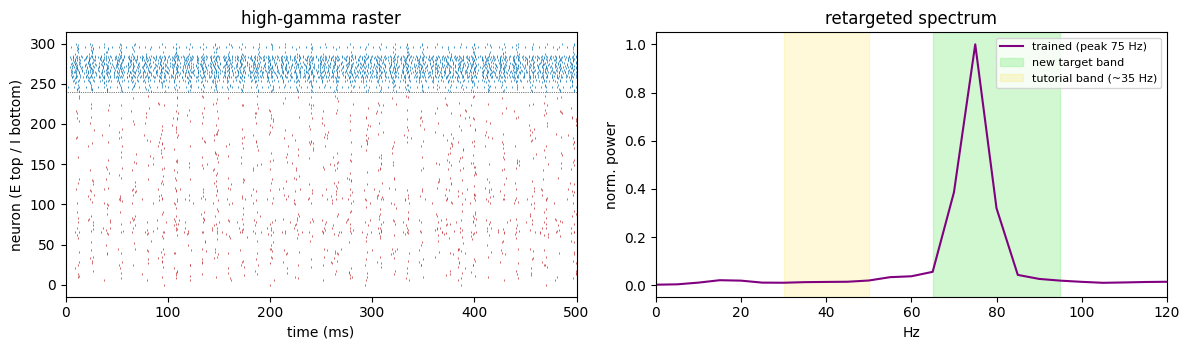

In [9]:
# fast inhibition + a shorter I->E delay -> aim for high gamma (~80 Hz)
exp1 = train_network(net_dir='net_p1', basis_inh=build_net.BASIS_INH_FAST, delay_ie=2.0,
                     target_band=(65., 95.), n_epochs=25, seed=0)
sp1 = exp1['roll_out'](1000)
f1, P1s, c1s, pk1s = spec(sp1, exp1['gi'], exp1['target_band'])
print(f"high-gamma network: band-contrast {c1s:.2f}, peak ~{pk1s:.0f} Hz  "
      f"(the tutorial network sat at ~35 Hz, c={c1:.2f})")

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
gv.raster(sp1[0], exp1['is_exc'], ax=ax[0], t0=0, t1=500); ax[0].set(xlim=(0, 500), title='high-gamma raster')
ax[1].plot(f1, P1s / (P1s.max() + 1e-9), color='purple', label=f'trained (peak {pk1s:.0f} Hz)')
ax[1].axvspan(*exp1['target_band'], color='#90ee90', alpha=0.4, label='new target band')
ax[1].axvspan(30, 50, color='gold', alpha=0.15, label='tutorial band (~35 Hz)')
ax[1].set(xlim=(0, 120), xlabel='Hz', ylabel='norm. power', title='retargeted spectrum'); ax[1].legend(fontsize=8)
fig.tight_layout()

### Problem 2 — Does the fine-scale synaptic structure matter?

Training set every recurrent weight individually. But how much of the rhythm lives in the *specific*
learned pattern of weights, versus just the *class-level* statistics (how strong E→E vs I→E synapses
are on average)? Test it by **shuffling the trained weights within each connection class**
(E→E, E→I, I→E, I→I): this preserves each class's sign and its distribution of magnitudes but
destroys which particular cell connects to which. If the rhythm survives, the class statistics are
enough; if it collapses, the fine-scale pattern matters.

`shuffle_recurrent_within_classes(cell, is_exc)` (helpers cell) does the shuffle in place.

band-contrast:  trained 0.88  ->  shuffled-within-class 0.51


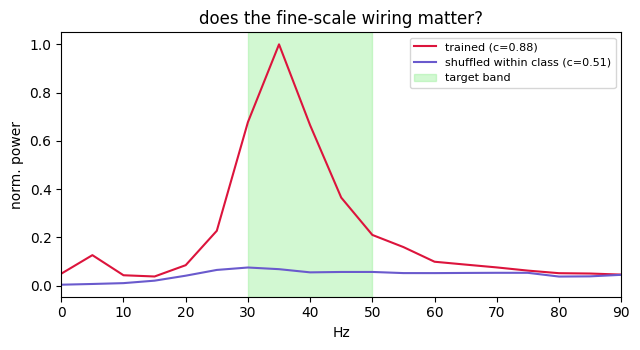

In [10]:
orig = cell.recurrent_weight_values.numpy().copy()          # snapshot the trained weights
sp_tr = roll_out(1000); _, P_tr, c_tr, _ = pop_spectrum(sp_tr)
shuffle_recurrent_within_classes(cell, is_exc, seed=0)      # permute within E->E, E->I, I->E, I->I
sp_sh = roll_out(1000); _, P_sh, c_sh, _ = pop_spectrum(sp_sh)
cell.recurrent_weight_values.assign(orig)                    # restore the trained network
if hasattr(cell, 'refresh_recurrent_weight_shadow'): cell.refresh_recurrent_weight_shadow()
print(f"band-contrast:  trained {c_tr:.2f}  ->  shuffled-within-class {c_sh:.2f}")

fig, ax = plt.subplots(figsize=(6.5, 3.6))
nrm = max(P_tr.max(), P_sh.max()) + 1e-9
ax.plot(freqs, P_tr / nrm, color='crimson',   label=f'trained (c={c_tr:.2f})')
ax.plot(freqs, P_sh / nrm, color='slateblue', label=f'shuffled within class (c={c_sh:.2f})')
ax.axvspan(*TARGET_BAND, color='#90ee90', alpha=0.4, label='target band')
ax.set(xlim=(0, 90), xlabel='Hz', ylabel='norm. power', title='does the fine-scale wiring matter?')
ax.legend(fontsize=8); fig.tight_layout()

### Problem 3 — How much do the other biophysical parameters constrain the rhythm?

Weights are only part of the story. The synaptic **kernel** shape, the **delays**, and the target
**rate distribution** all set the stage the weights act on. A useful way to see the kernel is to plot
the postsynaptic current one spike produces — `psc_kernel(basis_weights)` (helpers cell) does this.

**Try it:** replace the fast inhibitory kernel with a **slow** one (a long tail) and retrain with the
*same* 30–50 Hz target. Can weight training still build a clean gamma peak, or does the slow kernel
smear inhibition so no sharp rhythm forms? (You could also lengthen `delay_ie` or change
`rate_median_hz` and watch how the rhythm responds.)

[gamma/dpn] built SONATA net_dir: net_p3  (240 E + 60 I, 4E/4I cell variants, I->E delay 4.0ms, drive=100, bkg=100)
2026-07-09 23:25:29,244 [INFO] Created log file


2026-07-09 23:25:29,251 [INFO] TensorFlow precision policy set to "float32" (compute_dtype=float32, variable_dtype=float32, requested_dtype=float32).


INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0',)


2026-07-09 23:25:29,386 [INFO] Building "drive_input" inputs for drive


2026-07-09 23:25:29,387 [INFO] Building "bkg_input" inputs for bkg


slow-inhibition network: band-contrast 0.66  (fast inhibition reached c=0.88)


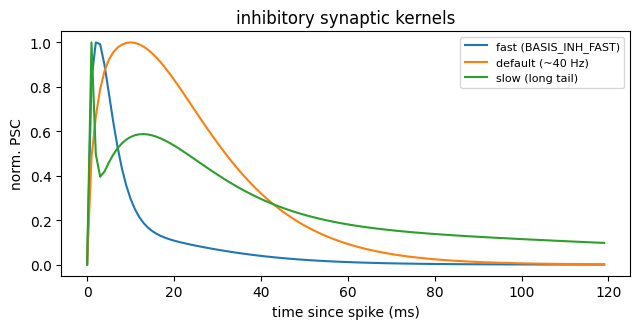

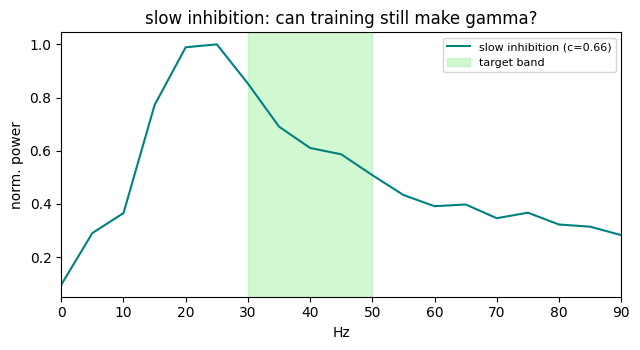

In [11]:
# (a) SEE the synaptic kernels: fast vs default vs slow
BASIS_INH_SLOW = [1.14, 0.06, 0.52, 0.13]     # a kernel with a long (~60 ms) tail
fig, ax = plt.subplots(figsize=(6.5, 3.4))
for name, bw in [('fast (BASIS_INH_FAST)', build_net.BASIS_INH_FAST),
                 ('default (~40 Hz)', build_net.BASIS_INH),
                 ('slow (long tail)', BASIS_INH_SLOW)]:
    t, k = psc_kernel(bw); ax.plot(t, k / (np.abs(k).max() + 1e-9), label=name)
ax.set(xlabel='time since spike (ms)', ylabel='norm. PSC', title='inhibitory synaptic kernels')
ax.legend(fontsize=8); fig.tight_layout()

# (b) retrain with the SLOW kernel, SAME 30-50 Hz target -> can a clean peak still form?
exp3 = train_network(net_dir='net_p3', basis_inh=BASIS_INH_SLOW, target_band=(30., 50.), n_epochs=25, seed=0)
sp3 = exp3['roll_out'](1000); f3, P3s, c3s, pk3s = spec(sp3, exp3['gi'], (30., 50.))
print(f"slow-inhibition network: band-contrast {c3s:.2f}  (fast inhibition reached c={c1:.2f})")

fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.plot(f3, P3s / (P3s.max() + 1e-9), color='teal', label=f'slow inhibition (c={c3s:.2f})')
ax.axvspan(30, 50, color='#90ee90', alpha=0.4, label='target band')
ax.set(xlim=(0, 90), xlabel='Hz', ylabel='norm. power', title='slow inhibition: can training still make gamma?')
ax.legend(fontsize=8); fig.tight_layout()

### Quick reference — the main knobs

| Knob | Where | Effect |
|---|---|---|
| `TARGET_BAND`, `build_net.DELAY_IE`, `build_net.BASIS_INH` | Section 2 / `build_net.py` | the rhythm's frequency |
| `RATE_MEDIAN_HZ`, `rate_sigma` | Section 2 / `build_net.py` | firing-rate realism (the EMD term) |
| `BATCH_SIZE`, `LEARNING_RATE`, `N_EPOCHS` | Section 2 | training stability / speed |
| `spectral_ref`, `n_groups`, `rate_dist_weight` | `config.train.json` | the loss definition |

The trained weights and spikes from the tutorial network are saved in `saved/`.